# Quantum Machine Learning with a TwoLocal Variational Classifier -- 4-Label Checkerboard (Optimized Qiskit)

This notebook is a **drop-in-equivalent, dramatically faster** version of
[`../Parallel_QML_Checkerboard4L.ipynb`](../Parallel_QML_Checkerboard4L.ipynb).
Same 4-class checkerboard dataset, same ZZFeatureMap + TwoLocal(4 qubits)
model, same SPSA optimizer, same Method 1 / Method 2 split, same results --
it just trains in seconds instead of being impractical to run.

This is the multiclass counterpart of
[`../../qiskit_optimized/Parallel_QML_Optimized.ipynb`](../../qiskit_optimized/Parallel_QML_Optimized.ipynb)
-- same three fixes, generalized to the 4-qubit ansatz (2 encoding qubits + 2
extra "workspace" qubits) and 4-way classification:

1. **Cache each data point's ZZFeatureMap matrix once** (it never changes
   across SPSA iterations), instead of rebuilding the encoder circuit from
   scratch on every cost evaluation.
2. **Derive matrices via Qiskit's own `ZZFeatureMap`/`TwoLocal` +
   `quantum_info.Operator`** (guaranteeing exact correctness), then apply
   them with batched NumPy instead of `transpile()` + `AerSimulator`.
3. **For Method 2, apply each data point's encoder matrix directly** to its
   own "branch" of the batch array, instead of asking Qiskit to synthesize a
   7-controlled arbitrary unitary with no ancilla qubits (the original's main
   bottleneck).

See [`README.md`](README.md) and [`benchmark.py`](benchmark.py) for the full
writeup and measured numbers (**~500x** faster per Method-1 evaluation; a
full 400-iteration training run drops from an estimated very long time to
~15-20 seconds).

## How to use this notebook
1. Edit the **Configuration** cell below.
2. *Run All*. Training that was previously impractical now finishes in seconds.

> **Note:** like the original, this notebook must be run with its working
> directory set to `multiclass/qiskit_optimized/`.

## 1. Configuration  *(the only cell you normally edit)*

In [12]:
# ============================ USER SETTINGS ============================
# Pick the instance:  an integer from 1 to 10
DATASET_NUM = 1

# What to do:
#   "load"  -> read the pre-computed results shipped in ../results (fast, no training)
#   "train" -> train the model live with SPSA -- now fast enough to actually run here
MODE = "train"

# Which circuit construction(s) to run / display:
#   [1]    -> only Method 1 (one circuit per sample)
#   [2]    -> only Method 2 (all samples in superposition)
#   [1, 2] -> both, shown side by side
METHODS = [1, 2]

# --- settings used only when MODE == "train" ---
MAXITER = 4000          # SPSA iterations (same default as the original notebook)
SEED    = 42             # random seed for the initial parameters (reproducibility)

# --- visualization ---
PLOT_DECISION_BOUNDARY = False   # draw the learned decision boundary (a bit slower)
GRID_RES = 60                    # resolution of the decision-boundary grid
# ======================================================================

assert 1 <= DATASET_NUM <= 10
assert MODE in {"load", "train"}
assert all(m in (1, 2) for m in METHODS) and len(METHODS) >= 1
print(f"Dataset : checkerboard-4L-4Q / dataset{DATASET_NUM}")
print(f"Mode    : {MODE}   |   Method(s): {METHODS}")

Dataset : checkerboard-4L-4Q / dataset1
Mode    : train   |   Method(s): [1, 2]


## 2. Imports

In [13]:
import os
import json
import glob
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from qiskit.circuit.library import ZZFeatureMap, TwoLocal

import sys
sys.path.insert(0, os.path.abspath("."))
from qc_core import Method1Classifier, Method2Classifier, two_local_num_params

warnings.filterwarnings("ignore")
np.random.seed(SEED)

# 4 discrete colors used throughout for the 4 classes (0, 1, 2, 3)
CLASS_COLORS = ListedColormap(["#3b4cc0", "#7ea0f9", "#f7a889", "#b40426"])
CLASS_NORM   = BoundaryNorm(np.arange(-0.5, 4.5, 1), CLASS_COLORS.N)

## 3. Load the selected dataset

Train data : (128, 2),  labels: (128,)
Test  data : (64, 2),  labels: (64,)
Classes    : [0, 1, 2, 3]


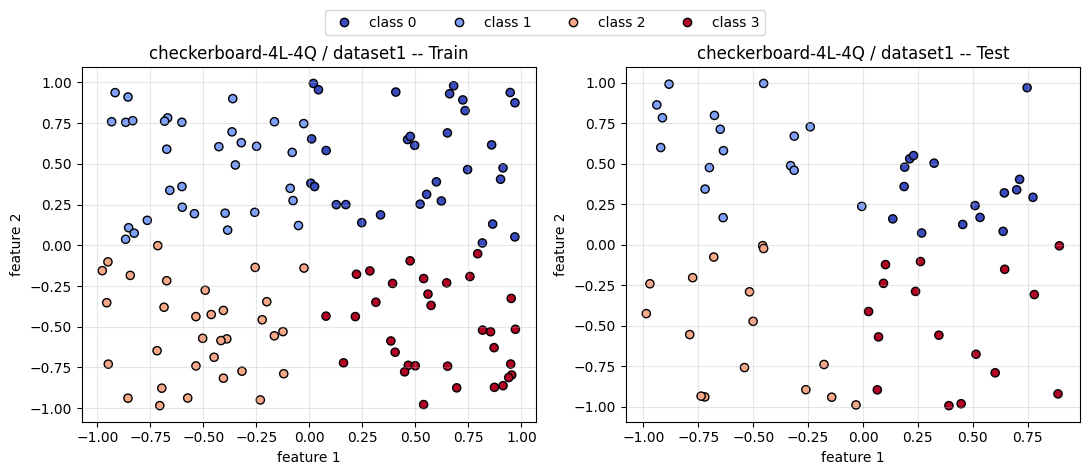

In [14]:
# os.path.abspath collapses ".." against cwd -- this project's path is deep
# enough that an un-resolved relative path can exceed Windows' 260-char
# MAX_PATH limit for some file APIs (see ../pennylane_implementation/README.md
# for the full story of this gotcha).
DATA_DIR    = os.path.abspath(os.path.join("..", "datasets", f"dataset{DATASET_NUM}"))
RESULTS_DIR = os.path.abspath(os.path.join("..", "results",  f"checkerboard-4L-4Q-dataset{DATASET_NUM}"))

train_data   = pd.read_csv(os.path.join(DATA_DIR, "train_data")).to_numpy()
train_labels = pd.read_csv(os.path.join(DATA_DIR, "train_labels")).to_numpy().flatten()
test_data    = pd.read_csv(os.path.join(DATA_DIR, "test_data")).to_numpy()
test_labels  = pd.read_csv(os.path.join(DATA_DIR, "test_labels")).to_numpy().flatten()

print(f"Train data : {train_data.shape},  labels: {train_labels.shape}")
print(f"Test  data : {test_data.shape},  labels: {test_labels.shape}")
print(f"Classes    : {sorted(np.unique(train_labels).tolist())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, X, y, name in [(axes[0], train_data, train_labels, "Train"),
                       (axes[1], test_data,  test_labels,  "Test")]:
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=CLASS_COLORS, norm=CLASS_NORM,
               edgecolors="k", s=35)
    ax.set_title(f"checkerboard-4L-4Q / dataset{DATASET_NUM} -- {name}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.grid(alpha=0.3)
handles = [plt.Line2D([0], [0], marker="o", color="w", markeredgecolor="k",
                      markerfacecolor=CLASS_COLORS(i), label=f"class {i}")
          for i in range(4)]
fig.legend(handles=handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

## 4. Quantum-circuit hyperparameters

In [15]:
num_reupload = 2
num_features = train_data.shape[1]

clf1 = Method1Classifier(n_features=num_features, num_reupload=num_reupload)
clf2 = Method2Classifier(n_features=num_features, num_reupload=num_reupload,
                          num_data=len(train_data)) if 2 in METHODS else None

num_parameters = clf1.num_parameters
num_ansatz_q = clf1.n_ansatz
num_register = clf2.n_index if clf2 is not None else int(np.log2(len(train_data)))

print(f"Re-uploads        : {num_reupload}")
print(f"Encoding qubits   : {num_features}")
print(f"Ansatz qubits     : {num_ansatz_q}  (encoding + workspace register)")
print(f"Index register    : {num_register} qubits  (Method 2)")
print(f"Trainable params  : {num_parameters}")
print(f"Classes           : {clf1.n_classes}  (2-bit readout: '00', '01', '10', '11')")

Re-uploads        : 2
Encoding qubits   : 2
Ansatz qubits     : 4  (encoding + workspace register)
Index register    : 7 qubits  (Method 2)
Trainable params  : 32
Classes           : 4  (2-bit readout: '00', '01', '10', '11')


## 5. Circuit definitions

Both methods use exactly the same circuit *structure* as the original
notebook -- a **ZZFeatureMap** encoder re-applied to the 2 encoding qubits at
every re-upload, feeding into a **TwoLocal** ansatz acting on all 4 qubits
(2 encoding + 2 extra "workspace" qubits), re-uploaded 2 times. The reference
building blocks are drawn below for context (unchanged from the original
notebook); the speedup comes entirely from how `qc_core.py` *evaluates* these
circuits across the dataset, not from a different circuit.

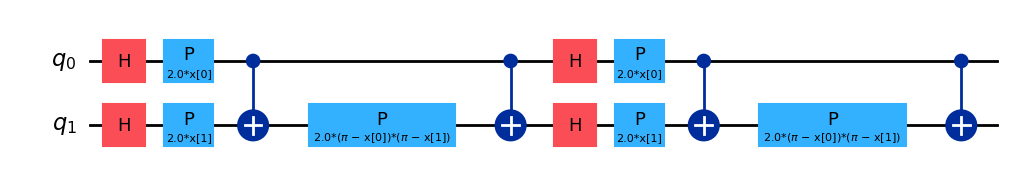

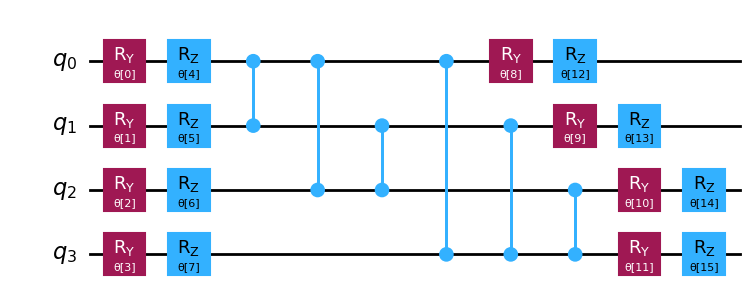

In [16]:
display(ZZFeatureMap(feature_dimension=num_features).decompose().draw('mpl'))
display(TwoLocal(num_ansatz_q, ['ry', 'rz'], 'cz', 'full', reps=1).decompose().draw('mpl'))

## 6. Training / evaluation functions

Accuracy is always measured with the Method-1 per-sample read-out, so trained
parameters from either method are evaluated consistently -- exactly as in the
original notebook. Labels are read out as 2-bit class indices (0-3).

In [17]:
def performance_evaluation(data, labels, variational):
    '''Return (accuracy, predictions) using the Method-1 read-out.'''
    return clf1.performance_evaluation(data, labels, variational)


def objective_function_1(variational):
    return clf1.cost(train_data, train_labels, variational)


def objective_function_2(variational):
    return clf2.cost(train_data, variational)


class OptimizerLog:
    '''Records SPSA progress and evaluates train/test accuracy each iteration.'''
    def __init__(self):
        self.evaluations, self.parameters, self.costs = [], [], []
        self.train_accuracies, self.test_accuracies, self.stepsizes = [], [], []

    def update(self, evaluation, parameter, cost, stepsize, accepted):
        self.evaluations.append(evaluation)
        self.parameters.append(parameter.copy())
        self.costs.append(cost)
        self.stepsizes.append(stepsize)
        tr, _ = performance_evaluation(train_data, train_labels, parameter)
        te, _ = performance_evaluation(test_data,  test_labels,  parameter)
        self.train_accuracies.append(tr)
        self.test_accuracies.append(te)
        print(f" Iter {len(self.evaluations):3d}: loss={cost:.4f}  "
              f"train_acc={tr:.4f}  test_acc={te:.4f}  step={stepsize:.4f}")

## 7. Run training **or** load the saved results

Same `qiskit_machine_learning.optimizers.SPSA` as the original notebook --
only the cost function underneath is fast now. The shipped result files are
timestamped dumps (`results_spsa_method{1,2}_<timestamp>.json`), so "load"
mode globs for the matching file per dataset/method, exactly like the
original notebook.

In [18]:
results = {}

for METHOD in METHODS:
    print(f"\n########## Method {METHOD} ##########")
    if MODE == "train":
        from qiskit_machine_learning.optimizers import SPSA
        print(f"Training Method {METHOD} with SPSA ({MAXITER} iterations)...\n")
        np.random.seed(SEED)
        initial_point = np.random.uniform(-np.pi, np.pi, size=num_parameters)
        log = OptimizerLog()
        objective = objective_function_1 if METHOD == 1 else objective_function_2
        optimizer = SPSA(maxiter=MAXITER, callback=log.update)

        t0 = time.time()
        result = optimizer.minimize(objective, initial_point)
        elapsed = time.time() - t0

        history = {
            "costs": log.costs,
            "train_accuracies": log.train_accuracies,
            "test_accuracies": log.test_accuracies,
            "stepsizes": log.stepsizes,
            "final_cost": float(result.fun),
        }
        final_params = result.x
        print(f"\nDone in {elapsed:.1f}s. Final cost = {result.fun:.6f}")

    else:  # MODE == "load"
        pattern = os.path.join(RESULTS_DIR, f"results_spsa_method{METHOD}_*.json")
        matches = sorted(glob.glob(pattern))
        assert matches, f"No result file found matching: {pattern}"
        json_path = matches[-1]
        print(f"Loading saved results from: {json_path}")
        with open(json_path, encoding="utf-8") as f:
            saved = json.load(f)
        th = saved["training_history"]
        fr = saved["final_results"]
        history = {
            "costs": th["costs"],
            "train_accuracies": th["train_accuracies"],
            "test_accuracies": th["test_accuracies"],
            "stepsizes": th["stepsizes"],
            "final_cost": fr["final_cost"],
        }
        final_params = np.array(fr["final_parameters"])
        print(f"Loaded {len(history['costs'])} iterations  "
              f"(optimizer: {saved['experiment_info']['optimizer']})")

        # Correctness check: re-evaluate the saved parameters with the
        # optimized classifier and confirm the predictions agree exactly.
        opt_test_acc, opt_test_pred = performance_evaluation(test_data, test_labels, final_params)
        agreement = np.mean([int(a == b) for a, b in zip(opt_test_pred, fr["test_predictions"])])
        print(f"Optimized re-evaluation: test_acc={opt_test_acc:.4f} "
              f"(original reported {fr['final_test_accuracy']:.4f}), "
              f"prediction agreement = {agreement:.4f}")

    results[METHOD] = {"history": history, "final_params": final_params}


########## Method 1 ##########
Training Method 1 with SPSA (4000 iterations)...

 Iter   1: loss=1.4184  train_acc=0.2500  test_acc=0.2500  step=0.3390
 Iter   2: loss=1.3568  train_acc=0.3359  test_acc=0.3750  step=2.4885
 Iter   3: loss=1.6038  train_acc=0.2500  test_acc=0.2812  step=4.5101
 Iter   4: loss=1.3190  train_acc=0.3906  test_acc=0.2969  step=4.0741
 Iter   5: loss=1.3695  train_acc=0.2969  test_acc=0.2344  step=3.1052
 Iter   6: loss=1.5403  train_acc=0.3203  test_acc=0.2500  step=3.6499
 Iter   7: loss=1.5024  train_acc=0.2891  test_acc=0.2188  step=1.0588
 Iter   8: loss=1.5229  train_acc=0.3281  test_acc=0.2969  step=1.9591
 Iter   9: loss=1.4809  train_acc=0.3516  test_acc=0.3281  step=1.2647
 Iter  10: loss=1.4735  train_acc=0.3672  test_acc=0.2656  step=0.4861
 Iter  11: loss=1.5085  train_acc=0.2891  test_acc=0.2969  step=2.2621
 Iter  12: loss=1.4997  train_acc=0.3047  test_acc=0.3281  step=1.3436
 Iter  13: loss=1.4818  train_acc=0.3203  test_acc=0.2969  step=1.

## 8. Training curves

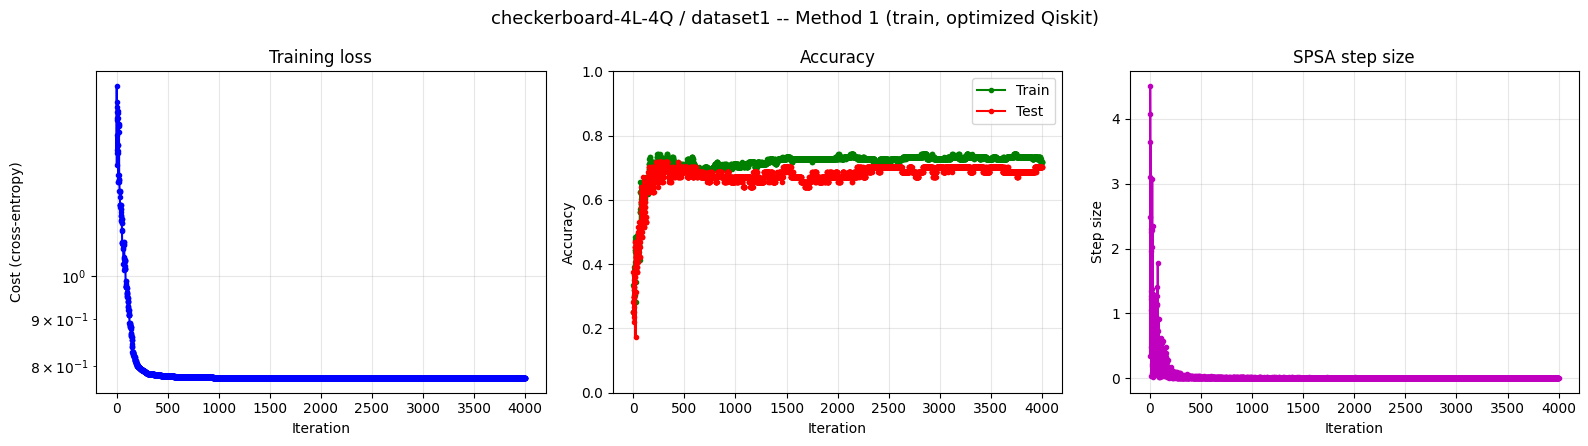

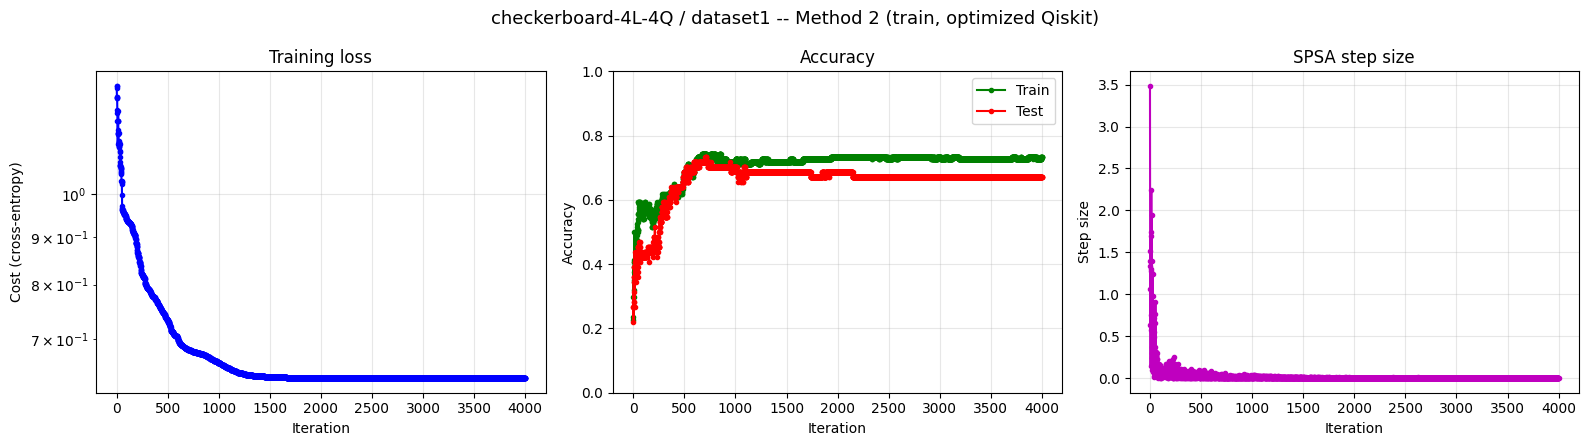

In [20]:
for METHOD in METHODS:
    history = results[METHOD]["history"]
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(history["costs"], 'b-o', ms=3)
    ax[0].set_yscale('log'); ax[0].set_title("Training loss")
    ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("Cost (cross-entropy)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(history["train_accuracies"], 'g-o', ms=3, label="Train")
    ax[1].plot(history["test_accuracies"],  'r-o', ms=3, label="Test")
    ax[1].set_ylim(0, 1); ax[1].set_title("Accuracy")
    ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Accuracy")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].plot(history["stepsizes"], 'm-o', ms=3)
    ax[2].set_title("SPSA step size")
    ax[2].set_xlabel("Iteration"); ax[2].set_ylabel("Step size")
    ax[2].grid(alpha=0.3)

    fig.suptitle(f"checkerboard-4L-4Q / dataset{DATASET_NUM} -- Method {METHOD} ({MODE}, optimized Qiskit)",
                 fontsize=13)
    plt.tight_layout(); plt.show()

## 9. Predictions and decision boundary

Predictions are computed with the trained parameters. The decision boundary
(4 discrete classes) is evaluated on a grid using the Method-1 read-out (set
`PLOT_DECISION_BOUNDARY=False` in the config to skip the slower grid evaluation).

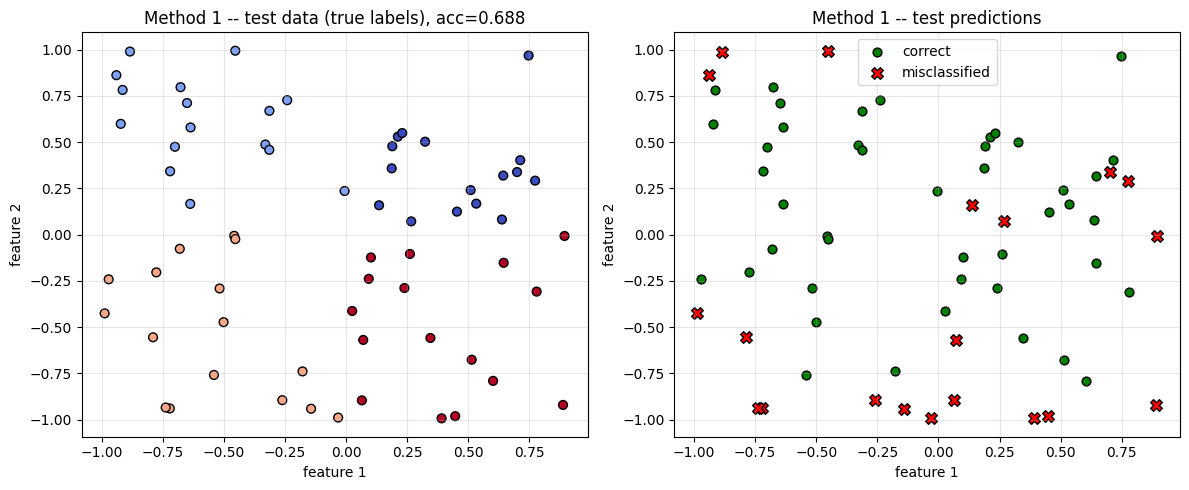

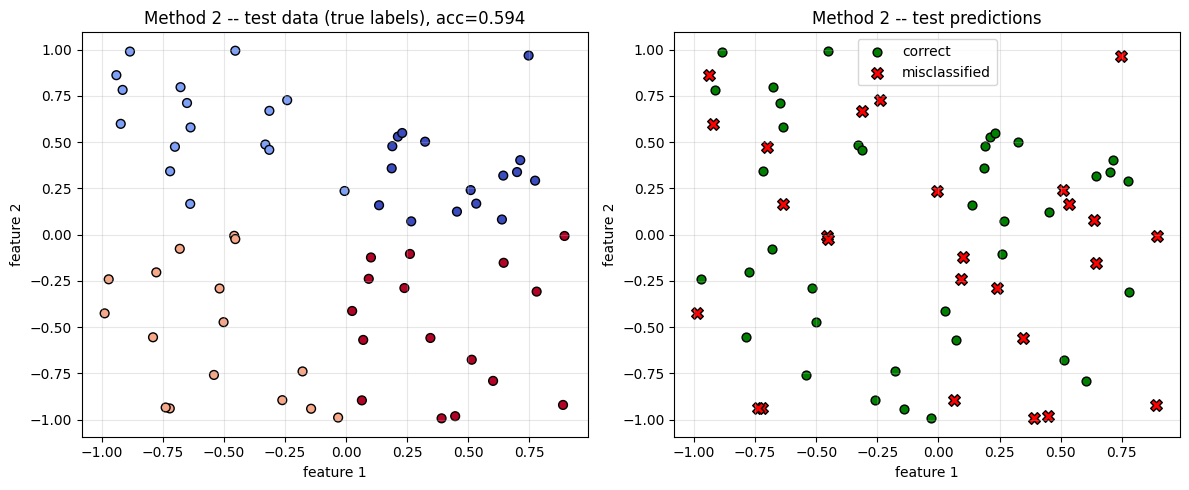

In [11]:
if PLOT_DECISION_BOUNDARY:
    allX = np.vstack([train_data, test_data])
    pad = 0.2
    x_min, x_max = allX[:, 0].min() - pad, allX[:, 0].max() + pad
    y_min, y_max = allX[:, 1].min() - pad, allX[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, GRID_RES),
                         np.linspace(y_min, y_max, GRID_RES))
    grid = np.c_[xx.ravel(), yy.ravel()]

for METHOD in METHODS:
    final_params = results[METHOD]["final_params"]
    final_train_acc, train_pred = performance_evaluation(train_data, train_labels, final_params)
    final_test_acc,  test_pred  = performance_evaluation(test_data,  test_labels,  final_params)
    test_pred = np.array(test_pred)
    results[METHOD]["final_train_acc"] = final_train_acc
    results[METHOD]["final_test_acc"]  = final_test_acc

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if PLOT_DECISION_BOUNDARY:
        print(f"Method {METHOD}: evaluating {GRID_RES}x{GRID_RES} decision-boundary grid...")
        probs = clf1.classification_probability(grid, final_params)
        zz = np.argmax(probs, axis=1).reshape(xx.shape)
        for ax in axes:
            ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
                       cmap=CLASS_COLORS, norm=CLASS_NORM, alpha=0.45)

    ax = axes[0]
    ax.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, cmap=CLASS_COLORS,
               norm=CLASS_NORM, edgecolors="k", s=40)
    ax.set_title(f"Method {METHOD} -- test data (true labels), acc={final_test_acc:.3f}")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2"); ax.grid(alpha=0.3)

    ax = axes[1]
    correct = test_pred == test_labels
    ax.scatter(test_data[correct, 0], test_data[correct, 1], c="green",
               edgecolors="k", s=40, label="correct")
    ax.scatter(test_data[~correct, 0], test_data[~correct, 1], c="red",
               marker="X", edgecolors="k", s=70, label="misclassified")
    ax.set_title(f"Method {METHOD} -- test predictions")
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

## 10. Final performance summary

In [10]:
print(f"Dataset: checkerboard-4L-4Q / dataset{DATASET_NUM}    Mode: {MODE}    Implementation: optimized Qiskit\n")

rows = []
for METHOD in METHODS:
    h = results[METHOD]["history"]
    rows.append({
        "method": METHOD,
        "final_train_acc": round(results[METHOD]["final_train_acc"], 4),
        "final_test_acc":  round(results[METHOD]["final_test_acc"], 4),
        "best_test_acc":   round(max(h["test_accuracies"]), 4),
        "best_train_acc":  round(max(h["train_accuracies"]), 4),
        "final_cost":      round(h["final_cost"], 6),
    })

summary_methods = pd.DataFrame(rows).set_index("method")
display(summary_methods)

Dataset: checkerboard-4L-4Q / dataset1    Mode: load    Implementation: optimized Qiskit



,final_train_acc,final_test_acc,best_test_acc,best_train_acc,final_cost
method,,,,,
1,0.7188,0.6406,0.7500,0.7812,0.707387
2,0.7109,0.6719,0.6875,0.7344,0.661091


## 11. (Optional) Compare all 10 instances

A quick aggregate view across `dataset1` ... `dataset10` for the chosen
`METHOD`, read from the saved results shipped with the original notebook.
This does not depend on the single-dataset selection above.


===== checkerboard-4L-4Q -- Method 1 (all 10 instances) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.6406,0.7500,0.7188,0.7074
2,0.6875,0.7656,0.6641,0.7877
3,0.4688,0.5000,0.5391,1.0882
4,0.4531,0.5469,0.6250,1.0376
5,0.7031,0.7812,0.7734,0.7633
6,0.7188,0.7969,0.7812,0.7197
7,0.3594,0.4219,0.4688,1.2020
8,0.7344,0.7500,0.7188,0.7444
9,0.4062,0.4844,0.6016,1.0314


Mean final test accuracy: 0.5687 +/- 0.1429


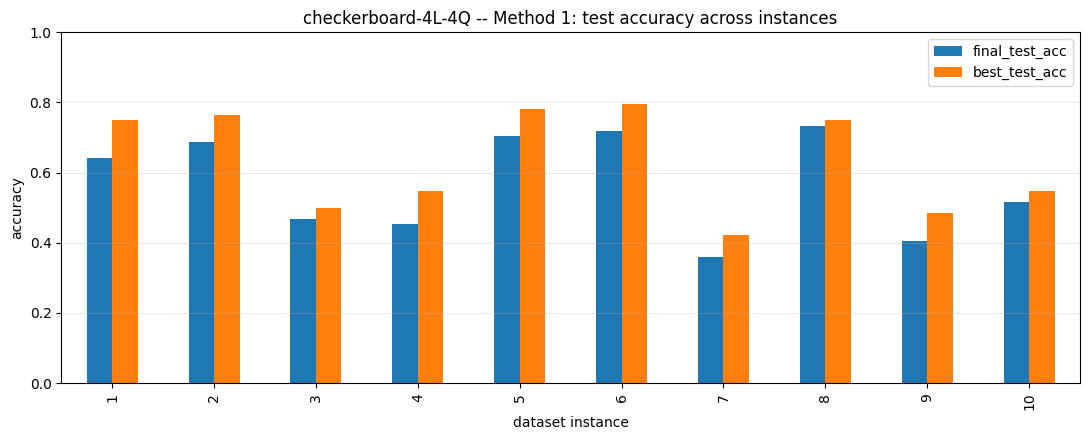


===== checkerboard-4L-4Q -- Method 2 (all 10 instances) =====


,final_test_acc,best_test_acc,final_train_acc,final_cost
dataset,,,,
1,0.6719,0.6875,0.7109,0.6611
2,0.4844,0.5000,0.4922,0.8714
3,0.7656,0.8438,0.7188,0.6841
4,0.6719,0.7500,0.6719,0.6079
5,0.5156,0.5781,0.5469,0.7699
6,0.5938,0.6250,0.6250,0.7805
7,0.5469,0.6094,0.5547,0.8357
8,0.5625,0.6562,0.4609,0.9412
9,0.4844,0.5000,0.5859,0.8033


Mean final test accuracy: 0.5828 +/- 0.0929


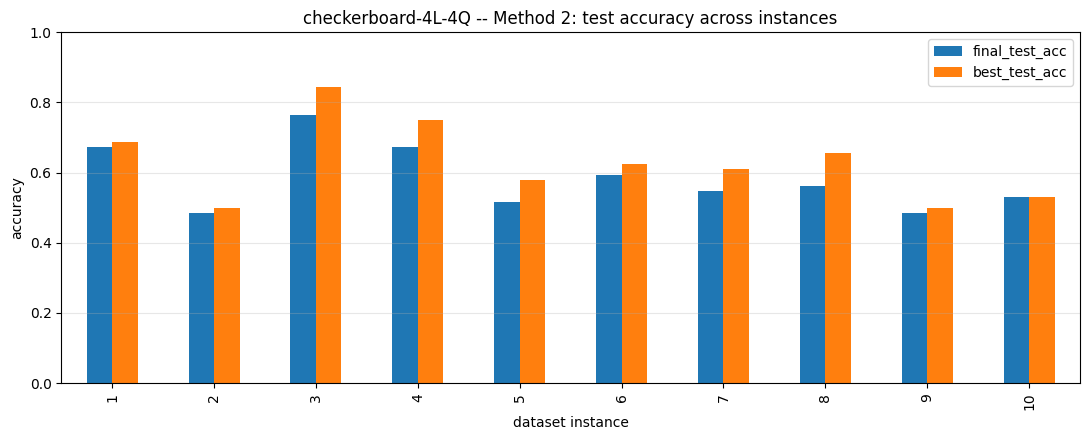

In [11]:
for METHOD in METHODS:
    rows = []
    for n in range(1, 11):
        pattern = os.path.abspath(os.path.join("..", "results", f"checkerboard-4L-4Q-dataset{n}",
                                                f"results_spsa_method{METHOD}_*.json"))
        matches = sorted(glob.glob(pattern))
        if not matches:
            continue
        with open(matches[-1], encoding="utf-8") as f:
            s = json.load(f)
        fr, th = s["final_results"], s["training_history"]
        rows.append({
            "dataset": n,
            "final_test_acc": fr["final_test_accuracy"],
            "best_test_acc":  max(th["test_accuracies"]),
            "final_train_acc": fr["final_train_accuracy"],
            "final_cost": fr["final_cost"],
        })

    summary = pd.DataFrame(rows).set_index("dataset")
    print(f"\n===== checkerboard-4L-4Q -- Method {METHOD} (all 10 instances) =====")
    display(summary.round(4))
    print(f"Mean final test accuracy: "
          f"{summary['final_test_acc'].mean():.4f} +/- {summary['final_test_acc'].std():.4f}")

    ax = summary[["final_test_acc", "best_test_acc"]].plot.bar(figsize=(11, 4.5))
    ax.set_title(f"checkerboard-4L-4Q -- Method {METHOD}: test accuracy across instances")
    ax.set_xlabel("dataset instance"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## 12. Speed comparison vs. the original implementation

A direct, reproducible benchmark against the original `qc1()`/`qc2()` +
`AerSimulator` + `transpile()` approach, on the same data and parameters (see
[`benchmark.py`](benchmark.py) for the standalone version of this).

In [12]:
import subprocess
result = subprocess.run(["python", "benchmark.py"], cwd=".", capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

=== Method 1: original vs optimized, full 128-point training set ===
  original   : 6.560s/evaluation   cost=1.563736
  optimized  : 0.872s (1st call, builds cache)   cost=1.563736
  optimized  : 0.014s (cache warm, as in every SPSA iteration after the 1st)
  cost match : diff=2.00e-15
  speedup (warm cache, the relevant number for a 400-iteration training run): 458x

=== Method 2: original approach's transpiled-circuit-size scaling ===
    (full n1=7/128-point case is infeasible to transpile in reasonable time;
     the optimized version handles it directly -- see below)
  n1=2 (  4 points): build+transpile=  0.33s   transpiled gate count=310
  n1=3 (  8 points): build+transpile=  0.97s   transpiled gate count=2,518

=== Method 2: optimized, full 128-point training set ===
  optimized  : 0.900s (1st call, builds cache)   cost=1.344014
  optimized  : 0.012s (cache warm, as in every SPSA iteration after the 1st)
  -> at this rate, a full 400-SPSA-iteration training run (3 cost evals/ite